<a href="https://colab.research.google.com/github/kenchigundikusumanjali-ai/ML-practical/blob/main/Practical_2_STUDENT_NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [610]:
# Practical 2: Data Preprocessing Techniques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [611]:
# Load Dataset
df = pd.read_csv("Bank_Marketing_Dataset.csv")



In [612]:


df = pd.read_csv("Bank_Marketing_Dataset.csv", sep=";")


In [613]:
print(df.columns.tolist())

['V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class']


In [614]:
df = pd.read_csv("Bank_Marketing_Dataset.csv", sep=",")

In [615]:
import os
print(os.listdir())

['.config', 'Bank_Marketing_Dataset.csv', 'preprocessing_pipeline.pkl', 'Bank_Marketing_Cleaned.csv', 'Bank_Marketing_Preprocessed.csv', 'sample_data']


In [616]:
df = pd.read_csv("Bank_Marketing_Dataset.csv")
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [617]:
df = pd.read_csv("Bank_Marketing_Dataset.csv", sep=",")
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [618]:
print(df.columns.tolist())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class']


In [619]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   V1      45211 non-null  int64 
 1   V2      45211 non-null  object
 2   V3      45211 non-null  object
 3   V4      45211 non-null  object
 4   V5      45211 non-null  object
 5   V6      45211 non-null  int64 
 6   V7      45211 non-null  object
 7   V8      45211 non-null  object
 8   V9      45211 non-null  object
 9   V10     45211 non-null  int64 
 10  V11     45211 non-null  object
 11  V12     45211 non-null  int64 
 12  V13     45211 non-null  int64 
 13  V14     45211 non-null  int64 
 14  V15     45211 non-null  int64 
 15  V16     45211 non-null  object
 16  Class   45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


In [620]:
print(df.shape)

(45211, 17)


In [621]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [622]:
# Missing Values
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [623]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [624]:
# Target and Features
X = df.drop("Class", axis=1)
y = df["Class"]


In [625]:
# Numerical and Categorical Columns

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:", numeric_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: Index(['V1', 'V6', 'V10', 'V12', 'V13', 'V14', 'V15'], dtype='object')
Categorical Columns: Index(['V2', 'V3', 'V4', 'V5', 'V7', 'V8', 'V9', 'V11', 'V16'], dtype='object')


In [626]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [627]:
# Numeric Pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [628]:
# Categorical Pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [629]:
# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

In [630]:
# Pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

In [631]:
# Fit & Transform
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Training Shape:", X_train_processed.shape)
print("Testing Shape:", X_test_processed.shape)

Training Shape: (36168, 51)
Testing Shape: (9043, 51)


In [632]:
# Save Pipeline
import pickle

with open("preprocessing_pipeline.pkl", "wb") as file:
    pickle.dump(pipeline, file)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [633]:
# Save Cleaned Dataset

df.to_csv("Bank_Marketing_Cleaned.csv", index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [634]:
# Save Preprocessed Dataset

import pandas as pd

processed_df = pd.DataFrame(X_train_processed)

processed_df.to_csv("Bank_Marketing_Preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [635]:
print("Total Null Values:", df.isnull().sum().sum())

Total Null Values: 0


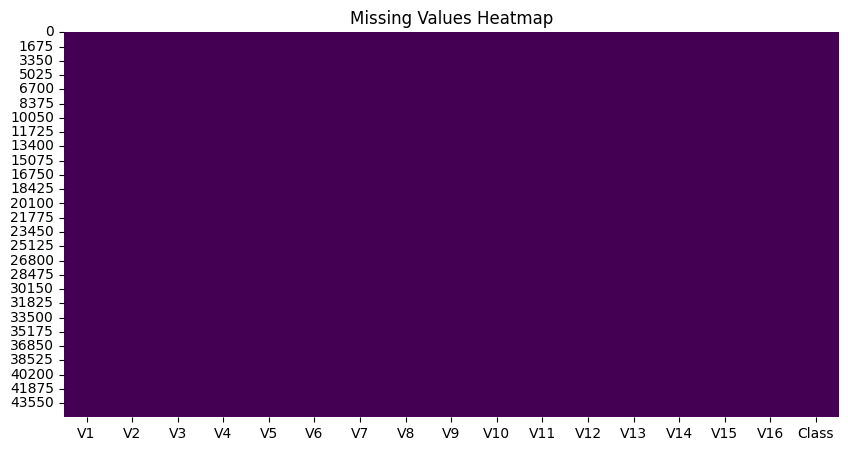

In [636]:
# Missing Values Heatmap

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

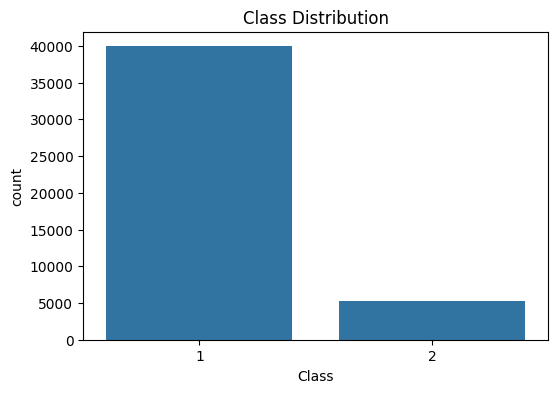

In [637]:
# Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

In [638]:
# Summary Statistics
df.describe()

,V1,V6,V10,V12,V13,V14,V15,Class
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,1.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,1.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,1.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,1.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,1.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,2.000000


In [639]:
# Download Files

from google.colab import files

files.download("Bank_Marketing_Cleaned.csv")
files.download("Bank_Marketing_Preprocessed.csv")
files.download("preprocessing_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Conclusion:
In this practical, the Bank Marketing dataset was successfully preprocessed. Missing values and duplicate records were checked and handled. Numerical features were scaled using StandardScaler, categorical features were encoded using OneHotEncoder, and a preprocessing pipeline was created using ColumnTransformer and Pipeline. The final dataset contained 0 null values and was saved along with the serialized preprocessing pipeline (preprocessing_pipeline.pkl). This preprocessing pipeline can be reused for future datasets.

##Boxplot (Before Outlier Removal)

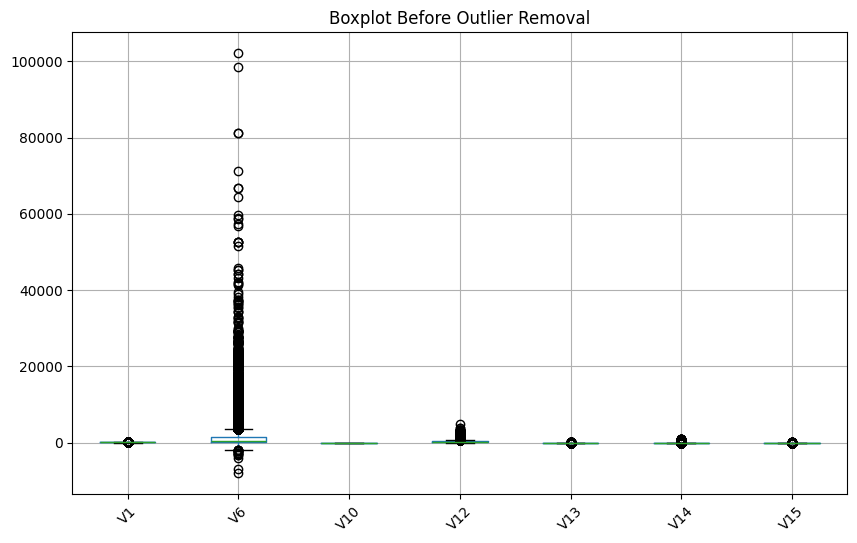

In [640]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
X[numeric_columns].boxplot()
plt.title("Boxplot Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

In [641]:
# IQR Method

Q1 = X[numeric_columns].quantile(0.25)
Q3 = X[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [642]:
# Remove Outliers

X_no_outliers = X[
    ~((X[numeric_columns] < lower_bound) |
      (X[numeric_columns] > upper_bound)).any(axis=1)
]

print("Original Shape:", X.shape)
print("Shape After Removing Outliers:", X_no_outliers.shape)

Original Shape: (45211, 16)
Shape After Removing Outliers: (28193, 16)


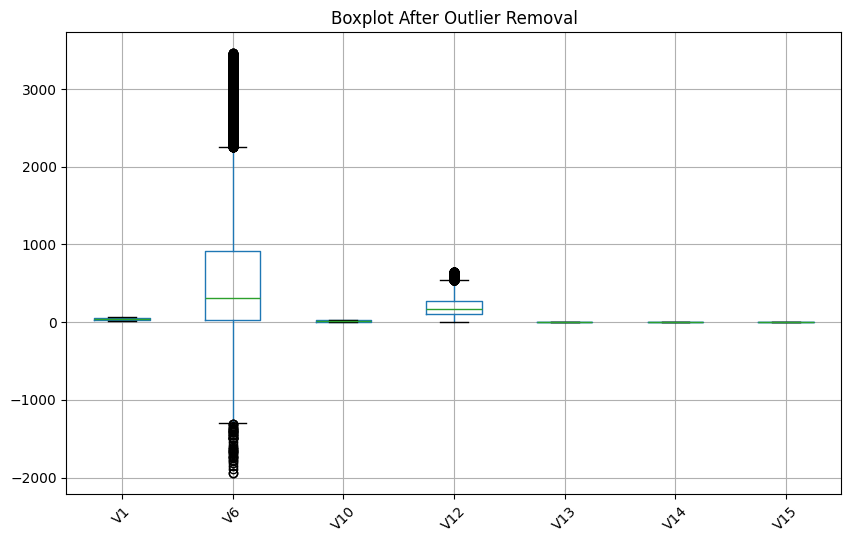

In [643]:
# Boxplot (After Outlier Removal)

plt.figure(figsize=(10,6))
X_no_outliers[numeric_columns].boxplot()
plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=45)
plt.show()

##Observation:
The IQR (Interquartile Range) method was used to detect and remove outliers from the numerical features. After removing outliers, the boxplots showed fewer extreme values, making the dataset more suitable for machine learning algorithms.

##Conclusion:
In this practical, data preprocessing was successfully performed on the Bank Marketing dataset. Missing values were checked and handled, duplicate records were removed, numerical features were standardized, categorical features were encoded, and outliers were detected using the IQR method. A preprocessing pipeline was created using ColumnTransformer and Pipeline, and the cleaned as well as preprocessed datasets were saved. The final dataset contained 0 null values and is ready for machine learning model training.